In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

# -----------------------------
# Setup
# -----------------------------

pd.set_option("display.max_columns", None)

# -----------------------------
# Load data
# -----------------------------

tudum = pd.read_csv("../content_libraries/netflix_top10.csv")

# Convert columns to appropriate types
tudum["week"] = pd.to_datetime(tudum["week"])
tudum["weekly_rank"] = pd.to_numeric(tudum["weekly_rank"])

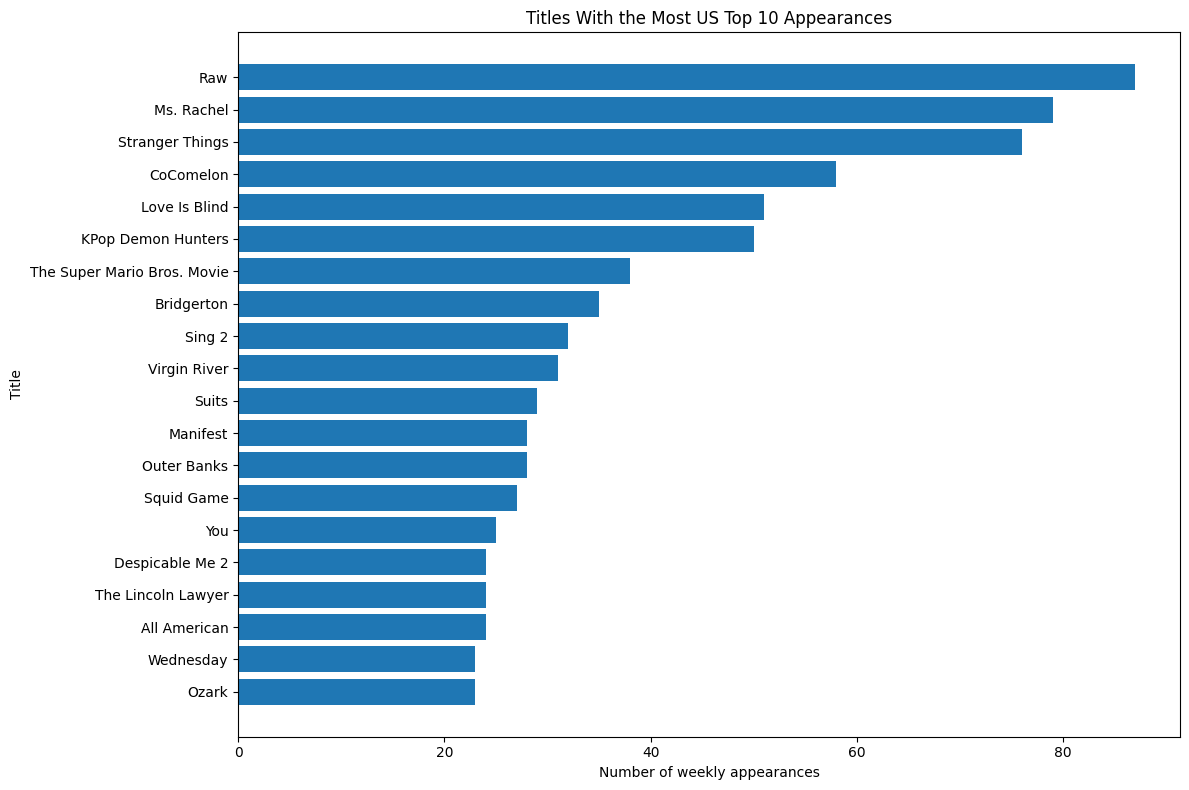

In [3]:
# ============================================================
# 1. Titles with the most Top 10 appearances
# ============================================================

top_titles = (
    tudum.groupby(["show_title", "category"])
      .size()
      .reset_index(name="weeks_in_top_10")
      .sort_values("weeks_in_top_10", ascending=False)
      .head(20)
)

plt.figure(figsize=(12, 8))

labels = top_titles["show_title"]
values = top_titles["weeks_in_top_10"]

plt.barh(labels, values)

plt.title("Titles With the Most US Top 10 Appearances")
plt.xlabel("Number of weekly appearances")
plt.ylabel("Title")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

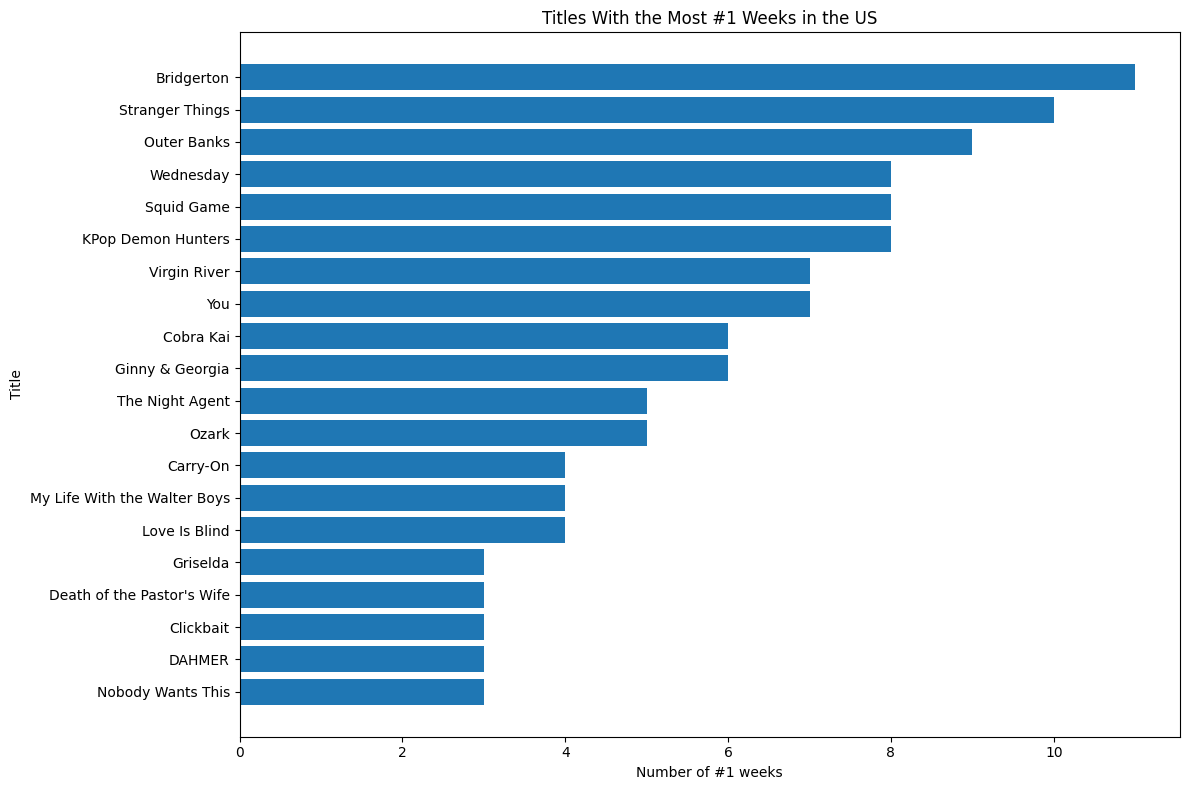

In [4]:
# ============================================================
# 2. Titles with the most #1 weeks
# ============================================================

number_one = (
    tudum[tudum["weekly_rank"] == 1]
    .groupby(["show_title", "category"])
    .size()
    .reset_index(name="number_one_weeks")
    .sort_values("number_one_weeks", ascending=False)
    .head(20)
)

plt.figure(figsize=(12, 8))

plt.barh(
    number_one["show_title"],
    number_one["number_one_weeks"]
)

plt.title("Titles With the Most #1 Weeks in the US")
plt.xlabel("Number of #1 weeks")
plt.ylabel("Title")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


In [5]:
catalogue_2026 = pd.read_csv("../content_libraries/netflix2026.csv")
catalogue_2023 = pd.read_csv("../content_libraries/netflix2023.csv")
catalogue_2022 = pd.read_csv("../content_libraries/netflix2022.csv")

tudum["week"] = pd.to_datetime(tudum["week"])

# ============================================================
# CLEAN TITLES
# ============================================================

def clean_title(x):
    return (
        str(x)
        .strip()
        .lower()
    )

tudum["title_clean"] = tudum["show_title"].apply(clean_title)
catalogue_2026["title_clean"] = catalogue_2026["title"].apply(clean_title)
catalogue_2023["title_clean"] = catalogue_2023["title"].apply(clean_title)
catalogue_2022["title_clean"] = catalogue_2022["title"].apply(clean_title)

In [6]:
# ============================================================
# CHECK MATCHES WITH CATALOGUE
# ============================================================

# Get unique Tudum titles
tudum_titles = set(tudum["title_clean"])

# Find matches in priority order
titles_2026 = set(catalogue_2026["title_clean"])
titles_2023 = set(catalogue_2023["title_clean"])
titles_2022 = set(catalogue_2022["title_clean"])

matches_2026 = tudum_titles.intersection(titles_2026)

remaining_after_2026 = tudum_titles - titles_2026
matches_2023 = remaining_after_2026.intersection(titles_2023)

remaining_after_2023 = remaining_after_2026 - titles_2023
matches_2022 = remaining_after_2023.intersection(titles_2022)

# Print matching results
print("Tudum unique titles:", len(tudum_titles))
print()
print("Matched in 2026:", len(matches_2026))
print("Additional matches in 2023:", len(matches_2023))
print("Additional matches in 2022:", len(matches_2022))
print()

total_matched = (
    len(matches_2026)
    + len(matches_2023)
    + len(matches_2022)
)

print("Total matched:", total_matched)

print(
    "Final match rate:",
    round(total_matched / len(tudum_titles) * 100, 2),
    "%"
)

# Mark which catalogue each title came from
catalogue_2026["catalogue_source"] = "2026"
catalogue_2023["catalogue_source"] = "2023"
catalogue_2022["catalogue_source"] = "2022"

# Combine catalogues in priority order
combined_catalogue = pd.concat(
    [
        catalogue_2026,
        catalogue_2023,
        catalogue_2022
    ],
    ignore_index=True
)

# Keep the first version of each title
# This gives priority to 2026, then 2023, then 2022
combined_catalogue = combined_catalogue.drop_duplicates(
    subset="title_clean",
    keep="first"
)

# Merge with Tudum
merged = pd.merge(
    tudum,
    combined_catalogue,
    on="title_clean",
    how="left",
    suffixes=("_tudum", "_catalogue")
)

# Show where matches came from
print("\nMATCH SOURCE")
print("------------")

print(
    merged["catalogue_source"]
    .fillna("No match")
    .value_counts()
)

# Show titles that still didn't match
print("\nTitles still unmatched:")

still_unmatched = (
    merged[
        merged["catalogue_source"].isna()
    ][["show_title", "category"]]
    .drop_duplicates()
    .sort_values("show_title")
)

print(
    still_unmatched.head(50).to_string(index=False)
)

Tudum unique titles: 1971

Matched in 2026: 1283
Additional matches in 2023: 104
Additional matches in 2022: 47

Total matched: 1434
Final match rate: 72.75 %

MATCH SOURCE
------------
catalogue_source
2026        4011
No match    1089
2023         279
2022          81
Name: count, dtype: int64

Titles still unmatched:
                                                                                       show_title category
                                                                       10 Things I Hate About You    Films
                                                                                      10,000 B.C.    Films
                                                                                       27 Dresses    Films
                                                                 30 for 30: O.J.: Made in America       TV
                                                                                              300    Films
                                    

In [7]:
# ============================================================
# SHOW TITLES STILL UNMATCHED
# ============================================================

still_unmatched = (
    merged[
        merged["genres"].isna()
    ][["show_title", "category"]]
    .drop_duplicates()
    .sort_values("show_title")
)

print("\nStill unmatched:")
print(
    still_unmatched.head(50).to_string(index=False)
)


Still unmatched:
                                                                                       show_title category
                                                                       10 Things I Hate About You    Films
                                                                                      10,000 B.C.    Films
                                                                                       27 Dresses    Films
                                                                 30 for 30: O.J.: Made in America       TV
                                                                                              300    Films
                                                                           300: Rise of an Empire    Films
                                                                                     3:10 to Yuma    Films
                                                                                               65    Films
                   

In [8]:
# ============================================================
# PARSE GENRES
# ============================================================

def parse_genres(x):
    if pd.isna(x):
        return []

    try:
        genres = ast.literal_eval(str(x))

        if isinstance(genres, list):

            # 2026 format:
            # [{'id': 'crime', 'name': 'Crime'}, ...]

            if len(genres) > 0 and isinstance(genres[0], dict):
                return [
                    g.get("name")
                    for g in genres
                    if "name" in g
                ]

            # 2023 format:
            # ['documentation', 'drama']

            return genres

    except:
        return []

    return []


merged["genre_list"] = merged[
    "genres"
].apply(parse_genres)

print("\nExample parsed genres:")
print(
    merged[
        ["show_title", "genres", "genre_list"]
    ]
    .dropna(subset=["genres"])
    .head(10)
    .to_string(index=False)
)

print(
    "\nTitles with at least one genre:",
    merged["genre_list"].apply(len).gt(0).sum()
)


Example parsed genres:
                           show_title                                                                                                                   genres                     genre_list
         Why Did I Get Married Again?                                                   [{'id': 'comedy', 'name': 'Comedy'}, {'id': 'drama', 'name': 'Drama'}]                [Comedy, Drama]
         The Seemingly Perfect Family                                                                                       [{'id': 'drama', 'name': 'Drama'}]                        [Drama]
The Ministry of Ungentlemanly Warfare                   [{'id': 'action', 'name': 'Action'}, {'id': 'comedy', 'name': 'Comedy'}, {'id': 'war', 'name': 'War'}]          [Action, Comedy, War]
         Puss in Boots: The Last Wish [{'id': 'action', 'name': 'Action'}, {'id': 'adventure', 'name': 'Adventure'}, {'id': 'animation', 'name': 'Animation'}] [Action, Adventure, Animation]
               Those Who W

In [9]:
# ============================================================
# CREATE YEAR
# ============================================================

merged["year"] = merged["week"].dt.year

# One row per genre
genre_data = merged.explode("genre_list")

genre_data = genre_data.dropna(
    subset=["genre_list"]
)

In [10]:
# ============================================================
# COUNT GENRE APPEARANCES
# ============================================================

genre_counts = (
    genre_data
    .groupby(
        ["year", "category", "genre_list"]
    )
    .size()
    .reset_index(name="appearances")
)

# Percentage within each year and category
genre_counts["percentage"] = (
    genre_counts["appearances"]
    /
    genre_counts
    .groupby(
        ["year", "category"]
    )["appearances"]
    .transform("sum")
    * 100
)

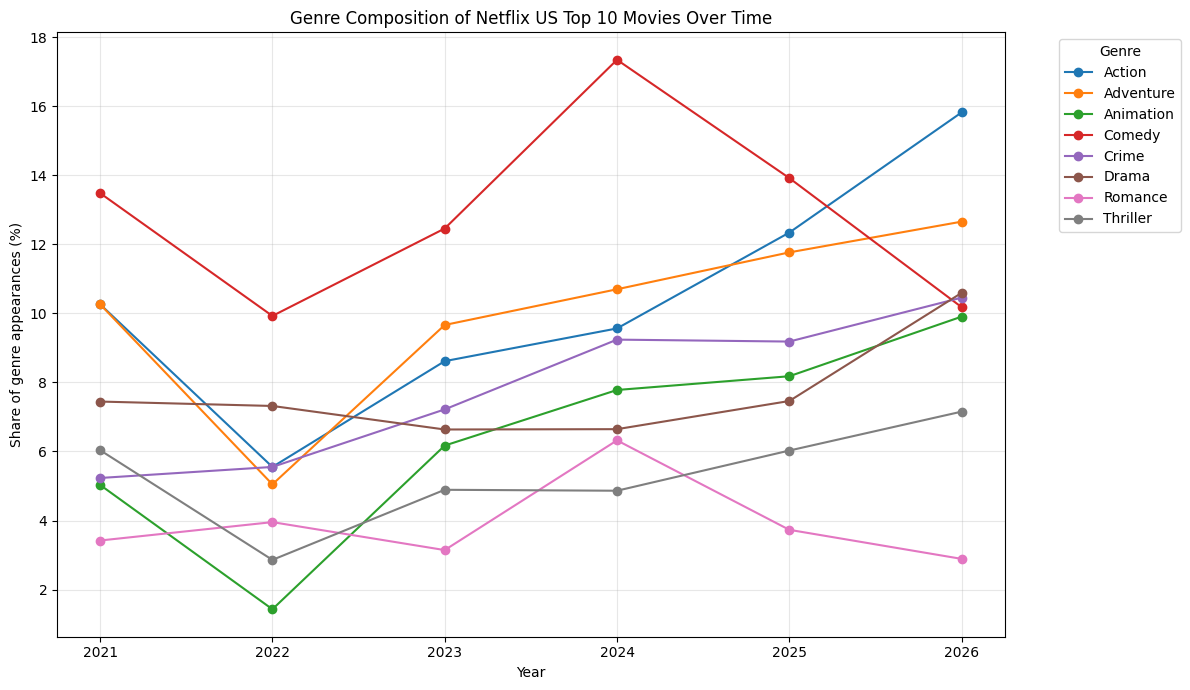

In [11]:
# ============================================================
# MOVIE GENRES
# ============================================================

movies = genre_counts[
    genre_counts["category"] == "Films"
].copy()

top_movie_genres = (
    movies
    .groupby("genre_list")["appearances"]
    .sum()
    .nlargest(8)
    .index
)

movies = movies[
    movies["genre_list"].isin(top_movie_genres)
]

movie_pivot = movies.pivot_table(
    index="year",
    columns="genre_list",
    values="percentage",
    fill_value=0
)

plt.figure(figsize=(12, 7))

for genre in movie_pivot.columns:
    plt.plot(
        movie_pivot.index,
        movie_pivot[genre],
        marker="o",
        label=genre
    )

plt.title(
    "Genre Composition of Netflix US Top 10 Movies Over Time"
)
plt.xlabel("Year")
plt.ylabel("Share of genre appearances (%)")
plt.legend(
    title="Genre",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


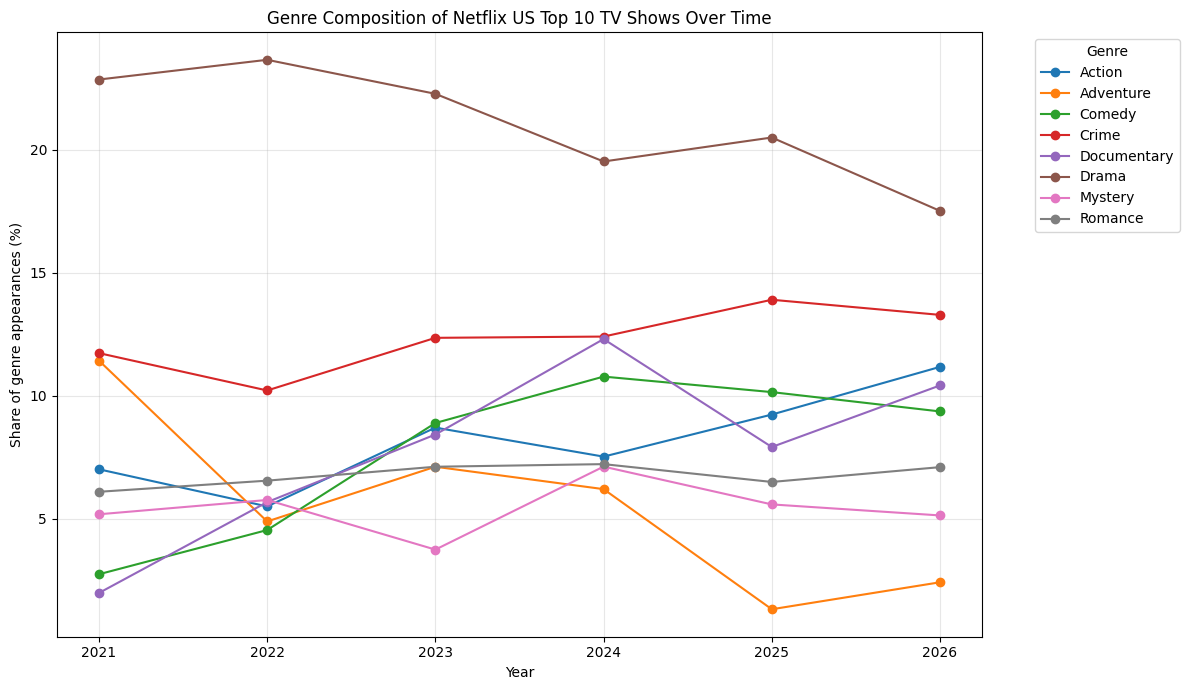

In [12]:
# ============================================================
# TV GENRES
# ============================================================

tv = genre_counts[
    genre_counts["category"] == "TV"
].copy()

top_tv_genres = (
    tv
    .groupby("genre_list")["appearances"]
    .sum()
    .nlargest(8)
    .index
)

tv = tv[
    tv["genre_list"].isin(top_tv_genres)
]

tv_pivot = tv.pivot_table(
    index="year",
    columns="genre_list",
    values="percentage",
    fill_value=0
)

plt.figure(figsize=(12, 7))

for genre in tv_pivot.columns:
    plt.plot(
        tv_pivot.index,
        tv_pivot[genre],
        marker="o",
        label=genre
    )

plt.title(
    "Genre Composition of Netflix US Top 10 TV Shows Over Time"
)
plt.xlabel("Year")
plt.ylabel("Share of genre appearances (%)")
plt.legend(
    title="Genre",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
# ============================================================
# PRINT THE RESULTS
# ============================================================

print("\nMOVIE GENRE PERCENTAGES")
print(movie_pivot.round(1))

print("\nTV GENRE PERCENTAGES")
print(tv_pivot.round(1))


MOVIE GENRE PERCENTAGES
genre_list  Action  Adventure  Animation  Comedy  Crime  Drama  Romance  \
year                                                                      
2021          10.3       10.3        5.0    13.5    5.2    7.4      3.4   
2022           5.6        5.0        1.4     9.9    5.6    7.3      4.0   
2023           8.6        9.7        6.2    12.5    7.2    6.6      3.1   
2024           9.6       10.7        7.8    17.3    9.2    6.6      6.3   
2025          12.3       11.8        8.2    13.9    9.2    7.5      3.7   
2026          15.8       12.7        9.9    10.2   10.5   10.6      2.9   

genre_list  Thriller  
year                  
2021             6.0  
2022             2.9  
2023             4.9  
2024             4.9  
2025             6.0  
2026             7.2  

TV GENRE PERCENTAGES
genre_list  Action  Adventure  Comedy  Crime  Documentary  Drama  Mystery  \
year                                                                        
2021          